In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Notebook settings
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid', palette='pastel')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Load Data
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
# Preview Data
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Basic Info
print("\nData Types:")
print(df.dtypes)


Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
# Clean TotalCharges
# Convert TotalCharges to numeric and handle blanks
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("\nNumber of null TotalCharges:", df['TotalCharges'].isna().sum())
#df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())


Number of null TotalCharges: 0


/var/folders/tk/4jb1qzdx3wlc5pst8r770vpw0000gn/T/ipykernel_45487/2640887825.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='coolwarm')


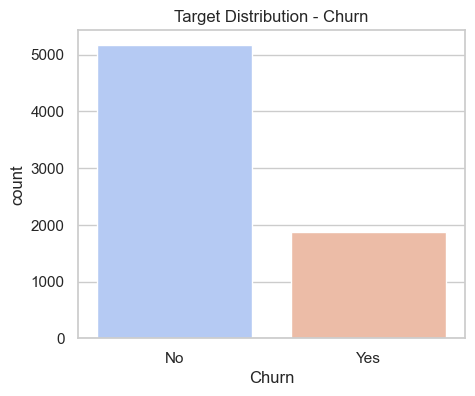

In [14]:
# Target Variable Distribution
plt.figure(figsize=(5, 4))
sns.countplot(x='Churn', data=df, palette='coolwarm')
plt.title('Target Distribution - Churn')
plt.show()

In [15]:
print("\nChurn Value Counts:")
print(df['Churn'].value_counts(normalize=True).round(3))


Churn Value Counts:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


In [16]:
# Numeric Summary
print("\nNumeric Columns Summary:")
display(df.describe())


Numeric Columns Summary:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


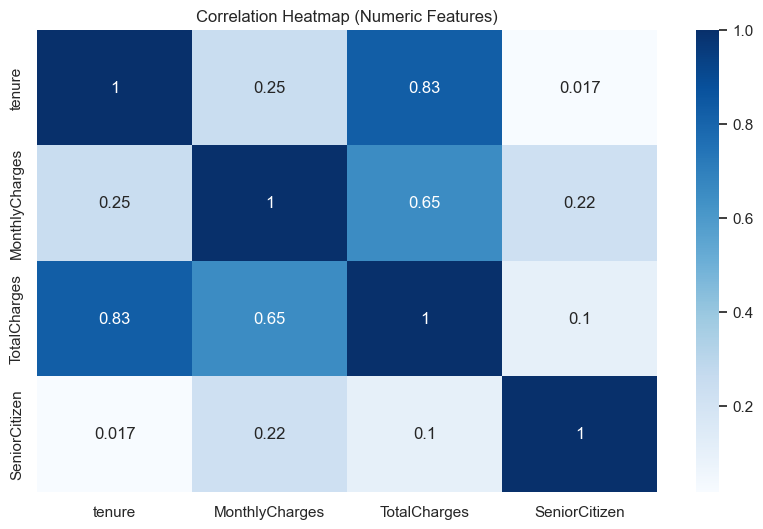

In [17]:
# Correlation Heatmap
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

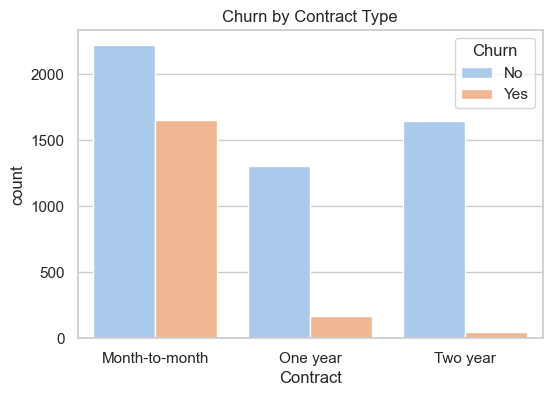

In [18]:
# Churn by Contract Type
plt.figure(figsize=(6, 4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.legend(title='Churn', loc='upper right')
plt.show()

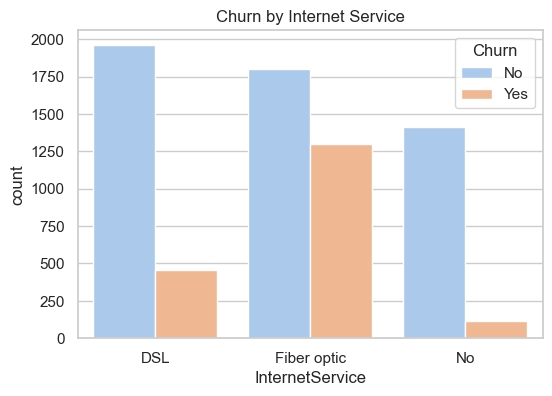

In [19]:
# Churn by Internet Service
plt.figure(figsize=(6, 4))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service')
plt.legend(title='Churn', loc='upper right')
plt.show()

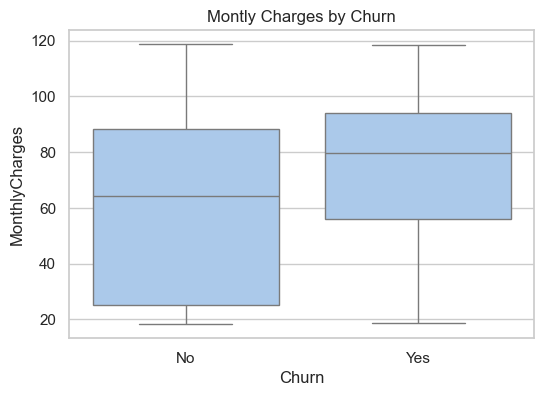

In [20]:
# Monthly Charges vs Churn
plt.figure(figsize=(6, 4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Montly Charges by Churn')
plt.show()

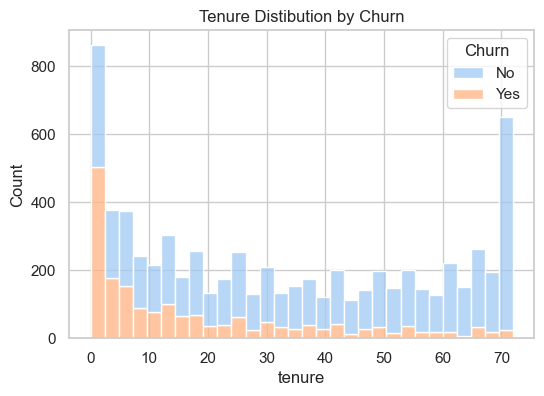

In [21]:
# Tenure vs Churn
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Tenure Distibution by Churn')
plt.show()

In [22]:
# --- Insights Summary ---
print("""
🧩 Quick Insights:
- Majority of customers are on month-to-month contracts.
- Churn is higher among customer with Fiber Optic Internet.
- Customers with short tenure and highter MonthlyCharges tend to churn more.
- TotalCharges correlates stronly with tenure.
""")


🧩 Quick Insights:
- Majority of customers are on month-to-month contracts.
- Churn is higher among customer with Fiber Optic Internet.
- Customers with short tenure and highter MonthlyCharges tend to churn more.
- TotalCharges correlates stronly with tenure.

